In [128]:
import numpy as np
import matplotlib.pyplot as plt   
from PostprocessingFunctions import write_vtk  

In [129]:
%%bash
cd ..
g++ -std=c++17 -Wall Airfoil.cpp SRC/Mesh.cpp SRC/Flux.cpp SRC/Simulation.cpp SRC/Solver.cpp SRC/Cell.cpp -o myprogram

        

SRC/Flux.cpp: In member function ‘std::pair<std::array<double, 4>, std::array<double, 4> > Flux::MusclExtrapolation(Cell*, char)’:
SRC/Flux.cpp:523:16: warning: unused variable ‘p1’ [-Wunused-variable]
  523 |         double p1; double p3;
      |                ^~
SRC/Flux.cpp:523:27: warning: unused variable ‘p3’ [-Wunused-variable]
  523 |         double p1; double p3;
      |                           ^~
SRC/Simulation.cpp: In member function ‘void Simulation::write_Cd(const string&)’:
SRC/Simulation.cpp:68:12: warning: unused variable ‘Cd’ [-Wunused-variable]
   68 |     double Cd = 0.0;
      |            ^~
SRC/Solver.cpp: In member function ‘void Solver::RK2_step()’:
SRC/Solver.cpp:55:16: warning: unused variable ‘is_mms’ [-Wunused-variable]
   55 |     const bool is_mms = inputs["is_mms"];
      |                ^~~~~~
SRC/Solver.cpp: In member function ‘void Solver::set_mms_bcs(Cell*)’:
SRC/Solver.cpp:260:12: warning: unused variable ‘gamma’ [-Wunused-variable]
  260 |     do

In [130]:
%%bash
cd ..
./myprogram

Shape = (9984, 4)
setting pointersSetting boundary types
Setting ambient Conditions...Setting inflow Conditions...Freestream Pressure: 67243.5   Freestream Density: 0.780993 Freestream vel257.857Iteration: 0
  Density   : 346.709  U-velocity: 89401.5  V-velocity: 12564.6  Pressure  : 1.16235e+08
Iteration: 1
  Density   : 281.225  U-velocity: 63790.9  V-velocity: 21349.9  Pressure  : 1.03349e+08
Iteration: 2
  Density   : 231.167  U-velocity: 44568.7  V-velocity: 34267.8  Pressure  : 9.17633e+07
Iteration: 3
  Density   : 194.455  U-velocity: 33042.4  V-velocity: 43473.5  Pressure  : 8.15011e+07
Iteration: 4
  Density   : 168.385  U-velocity: 29679.5  V-velocity: 49093.3  Pressure  : 7.25147e+07
Iteration: 5
  Density   : 150.007  U-velocity: 31659.4  V-velocity: 51777.9  Pressure  : 6.46667e+07
Iteration: 6
  Density   : 136.629  U-velocity: 35176.7  V-velocity: 52221.7  Pressure  : 5.77904e+07
Iteration: 7
  Density   : 126.165  U-velocity: 38299.2  V-velocity: 51061.3  Pressure  : 5

In [156]:
import matplotlib.pyplot as plt

data = np.loadtxt("../airfoil_primitives_coarse.csv", delimiter=",")
NI = 52
NJ = 192
print(data.shape)   # (4, Ncells)
rho = data[0, :].reshape((NI,NJ))
u   = data[1, :].reshape((NI,NJ))
v   = data[2, :].reshape((NI,NJ))
p   = data[3, :].reshape((NI,NJ))


(5, 9984)


In [132]:
rho.shape

(52, 192)

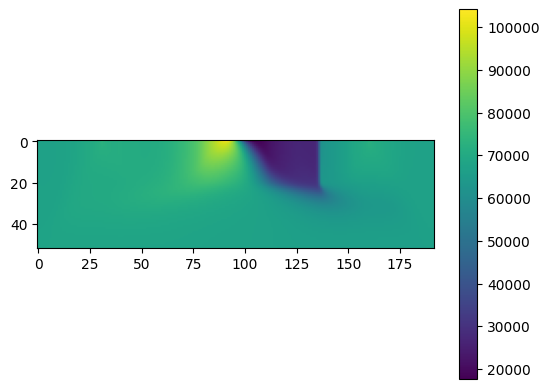

In [133]:

plt.imshow(p)
plt.colorbar()

In [134]:
from PostprocessingFunctions import load_grid
#x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.coarse.53x27.grd")
x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.medium.193x53.grd")
#x,y = load_grid("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.extra-coarse.27x14.grd")


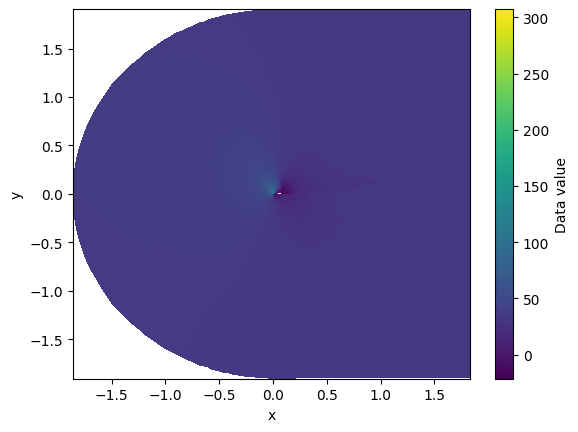

In [135]:
 

plt.pcolormesh(x[:,:], y[:,:], v[:,:], shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [136]:

nxi_top = -(y[:,1:]-y[:,0:-1])
nyi_top = x[:,1:]-x[:,0:-1]


nxi_top = -(y[:,1:]-y[:,0:-1])
nx = (-(nxi_top)[0:-1,:])[0,:]
ny = (-(nyi_top)[0:-1,:])[0,:]
p_at_face = p[0,:]+.5*(p[1,:]-p[0,:])

In [137]:
p_inf = 65855.8
rho_inf = 0.764876
V_inf = 291.639
chord = .1524
q_inf = .5*rho_inf*V_inf**2
q_inf
T_inf = 300
R = 287
p0 = 104532
M = .84

In [138]:
AoA_deg = 0
gamma = 1.4
alpha = 0
M      = 0.75
p_inf  = 67243.5     # Pa  (static)
T_inf  = 300.0       # K   (static)
R      = 287.0       # J/(kg·K)

rho_inf = p_inf/(R*T_inf)                     # 0.7809930314
a_inf   = np.sqrt(gamma*R*T_inf)              # 347.1887095 m/s
V_inf   = M*a_inf                             # 260.3915321 m/s
q_inf   = 0.5*rho_inf*V_inf**2                # 26477.128125 Pa

# For coefficients (2D, per unit span): A_ref = chord * 1
Den = q_inf * chord

# Flow-aligned unit vectors from AoA (degrees)
alpha = np.deg2rad(AoA_deg)
eD = np.array([np.cos(alpha), np.sin(alpha)])    # drag axis
eL = np.array([-np.sin(alpha), np.cos(alpha)])   # lift axis

# Example: pressure-only forces (Euler) with face normals and lengths
Fx = -np.sum(p_at_face * nx )
Fy = -np.sum(p_at_face * ny )
F  = np.array([Fx, Fy])

CD = (F @ eD) / Den
CL = (F @ eL) / Den

# Local Cp distribution
Cp = (p_at_face - p_inf) / q_inf

In [139]:
print(CD,CL)

0.015784679925588827 -1.273331787524353


-11.900403578740551

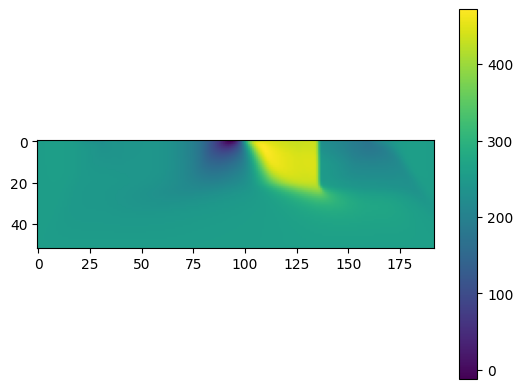

In [140]:
plt.imshow(u)

plt.colorbar()
np.min(u)

Drag Coefficient:  0.015784679925588827
Lift Coefficient:  1.2725389787878445
Pressure Coefficient -30.306514825080647


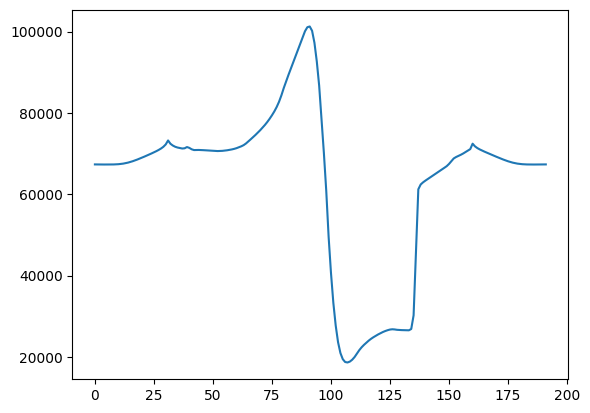

In [159]:
plt.plot(p_at_face)
Den = (.5*rho_inf*V_inf**2)*chord
print("Drag Coefficient: ",-np.sum(nx*p_at_face)/Den)
print("Lift Coefficient: ",np.sum((ny*p_at_face)[8*(4):-8*(4)]/Den))
print("Pressure Coefficient",(np.sum((p_at_face-p_inf)[8*(4):-8*(1)]*chord/Den)))

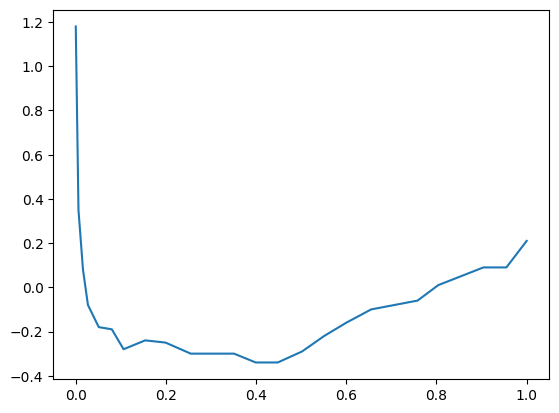

In [142]:
x1 = [0.0, 0.006, 0.016, 0.027, 0.051, 0.08, 0.106, 0.154, 0.199, 0.255,
     0.304, 0.351, 0.399, 0.448, 0.502, 0.551, 0.6, 0.655, 0.758, 0.804,
     0.904, 0.955, 1.0]

y1 = [1.18, 0.35, 0.08, -0.08, -0.18, -0.19, -0.28, -0.24, -0.25, -0.30,
     -0.30, -0.30, -0.34, -0.34, -0.29, -0.22, -0.16, -0.10, -0.06, 0.01,
      0.09, 0.09, 0.21]

plt.plot(x1,y1)

In [143]:
((x[-1,1:]+x[-1,0:-1])/2).shape

(192,)

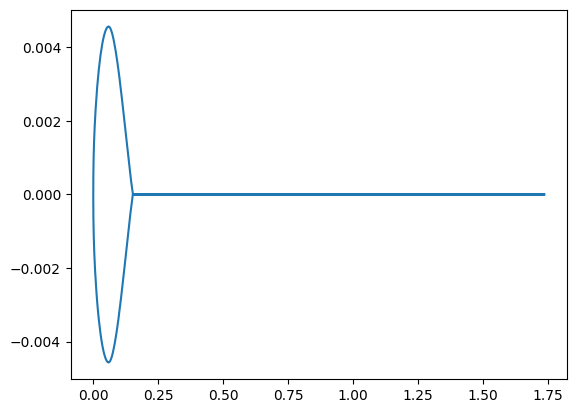

In [144]:
plt.plot((x[0,1:]+x[0,0:-1])/2,(y[0,1:]+y[0,0:-1])/2)

(-0.01, 0.1524)

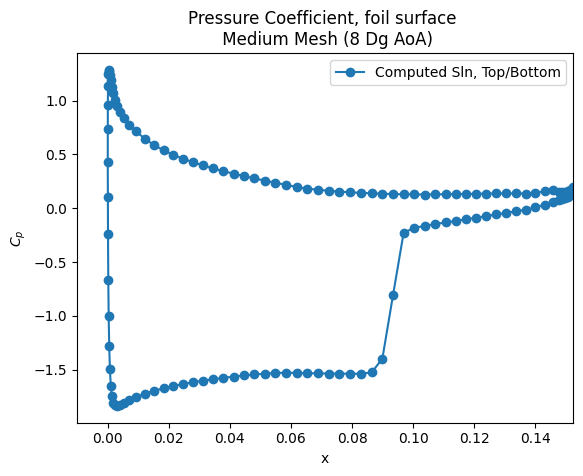

In [161]:
plt.title("Pressure Coefficient, foil surface \n Medium Mesh (8 Dg AoA)")
plt.plot(((x[0,1:]+x[0,0:-1])/2)[8*(4):-8*(4)], Cp[8*(4):-8*(4)],"-o",label="Computed Sln, Top/Bottom")
# plt.plot(np.array(x2)*chord,y2,"-o",label="underside")
# plt.plot(np.array(x1)*chord,y1,"-o",label="top")
plt.xlabel("x")
plt.ylabel(r"$C_p$")
plt.legend()
plt.xlim([-.01,chord])

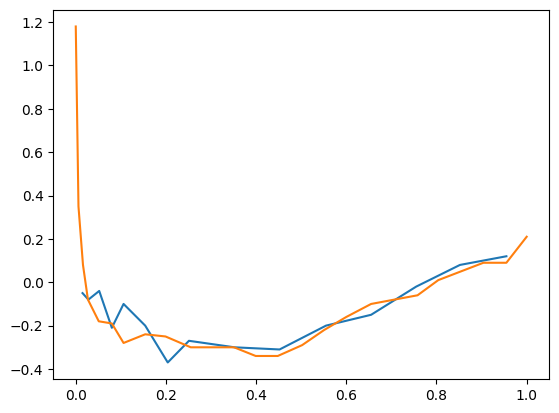

In [146]:
x2 = [0.015, 0.028, 0.052, 0.08, 0.106, 0.154, 0.204, 0.251, 0.352, 0.452,
      0.555, 0.655, 0.755, 0.852, 0.955]

y2 = [-0.05, -0.08, -0.04, -0.21, -0.10, -0.20, -0.37, -0.27, -0.30, -0.31,
      -0.20, -0.15, -0.02, 0.08, 0.12]
plt.plot(x2,y2)
plt.plot(x1,y1)

In [157]:
gamma = 1.4


V2 = u**2 + v**2
a2 = gamma * p / rho
M2 = V2 / a2
Mach = np.sqrt(M2)

In [148]:
u.shape

(52, 192)

In [155]:
Mach

array([[0.74788219, 0.74790423, 0.74782301, ..., 0.74782315, 0.74790425,
        0.74788211],
       [0.74788219, 0.74790411, 0.74782275, ..., 0.74782326, 0.74790421,
        0.74788197],
       [0.74788215, 0.74790392, 0.74782241, ..., 0.7478234 , 0.74790417,
        0.74788179],
       ...,
       [0.74377554, 0.7433896 , 0.74278938, ..., 0.75721017, 0.75686307,
        0.75666435],
       [0.74449605, 0.74412886, 0.74357044, ..., 0.75752073, 0.75718143,
        0.75697001],
       [0.74511389, 0.74482024, 0.74439934, ..., 0.7589664 , 0.75862981,
        0.75838542]])

In [158]:

write_vtk("/home/aaron99/src/CFD/CFD/CFD_FINAL3/Meshes/Airfoil/NACA64A006.medium.193x53.grd",Mach,u,v,p,output_name="../VTK/Airfoil_Medium_Mach_ROE.vtk")

In [151]:
import numpy as np, math
# D: [Supercoarse, Coarse, Medium]
D = np.array([0.025910345032662364, 0.018382755717889214, 0.01106595689793473], float)
r = 2.0
f3, f2, f1 = D

# apparent order
p = math.log((f3 - f2) / (f2 - f1), r)

# 3-grid Richardson (may be unreliable if not asymptotic)
D_ext_3 = f1 + (f1 - f2) / (r**p - 1)

# 2-grid extrapolations assuming formal order
D_ext_p1 = f1 + (f1 - f2) / (r**1 - 1)   # p=1
D_ext_p2 = f1 + (f1 - f2) / (r**2 - 1)   # p=2

print("p =", p)
print("D_ext_3 =", D_ext_3)
print("D_ext_p1 =", D_ext_p1)
print("D_ext_p2 =", D_ext_p2)


p = 0.040975329032753395
D_ext_3 = -0.24290918091718297
D_ext_p1 = 0.0037491580779802462
D_ext_p2 = 0.008627023957949903


ValueError: not enough values to unpack (expected 2, got 0)

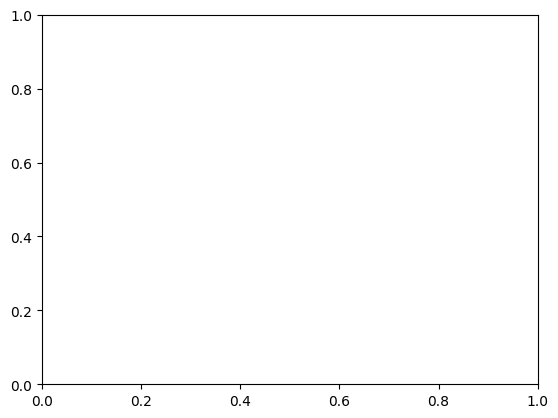

In [152]:
 

plt.pcolormesh(x, y, p, shading='auto', cmap='viridis')
plt.colorbar(label="Data value")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [ ]:
plt.contour(x,y,Mach)